# 04 — PubMedBERT Model Training

This notebook trains a domain-specific transformer (PubMedBERT)
for biomedical question answering.

Objective:
To evaluate whether domain-specific models outperform baseline BERT.

Pipeline:
- Load processed dataset
- Tokenize text
- Handle class imbalance (oversampling + class weights)
- Train model
- Evaluate performance

## 1. Import Libraries

In [1]:
import numpy as np
import torch
from datasets import load_from_disk, concatenate_datasets
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.utils.class_weight import compute_class_weight
from torch.nn import CrossEntropyLoss

## 2. Load Dataset

In [2]:
dataset = load_from_disk("data/processed/pubmedqa")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['pubid', 'question', 'context', 'long_answer', 'final_decision', 'input_text', 'label'],
        num_rows: 800
    })
    test: Dataset({
        features: ['pubid', 'question', 'context', 'long_answer', 'final_decision', 'input_text', 'label'],
        num_rows: 200
    })
})


## 3. Load PubMedBERT Tokenizer

In [3]:
model_name = "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext"

tokenizer = AutoTokenizer.from_pretrained(model_name)

## 4. Tokenize Dataset

In [4]:
def tokenize_function(example):
    return tokenizer(
        example["input_text"],
        padding="max_length",
        truncation=True,
        max_length=512
    )

dataset = dataset.map(tokenize_function, batched=True)

## 5. Format Dataset for PyTorch

In [5]:
dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

## 6. Handle Class Imbalance (Oversampling)

In [6]:
train_data = dataset["train"]

yes_data = train_data.filter(lambda x: x["label"] == 0)
no_data = train_data.filter(lambda x: x["label"] == 1)
maybe_data = train_data.filter(lambda x: x["label"] == 2)

oversampled_maybe = concatenate_datasets([maybe_data] * 3)

balanced_train = concatenate_datasets([yes_data, no_data, oversampled_maybe])

print("Balanced size:", len(balanced_train))

Balanced size: 970


## 7. Compute Class Weights

In [7]:
labels = np.array(dataset["train"]["label"])
classes = np.unique(labels)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float)

print("Class Weights:", class_weights)

Class Weights: tensor([0.5939, 1.0025, 3.1373])


## 9. Define Evaluation Metrics

In [8]:
def compute_metrics(pred):
    logits, labels = pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

## 10. Training Arguments

In [9]:
training_args = TrainingArguments(
    output_dir="./results_pubmedbert",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
)

## 11. Define Weighted Trainer

In [10]:
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels") if "labels" in inputs else inputs.get("label")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = CrossEntropyLoss(weight=class_weights.to(model.device))
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [13]:
print("Model exists:", 'model' in globals())

Model exists: True


In [14]:
print("Training args exists:", 'training_args' in globals())

Training args exists: True


In [15]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['pubid', 'question', 'context', 'long_answer', 'final_decision', 'input_text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 800
    })
    test: Dataset({
        features: ['pubid', 'question', 'context', 'long_answer', 'final_decision', 'input_text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 200
    })
})


In [16]:
print("Model exists:", 'model' in globals())
print("Training args exists:", 'training_args' in globals())
print("Balanced train exists:", 'balanced_train' in globals())
print("Compute metrics exists:", callable(compute_metrics))

Model exists: True
Training args exists: True
Balanced train exists: True
Compute metrics exists: True


## 12. Initialize Trainer

In [17]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=balanced_train,
    eval_dataset=dataset["test"],
    compute_metrics=compute_metrics,
)

## 13. Train Model

In [18]:
trainer.train()

/Users/jishnusmacbook/Documents/GitHub/ANN-Bike_Sharing-Boston_Housing/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,1.132579,0.260000,0.650577,0.260000,0.261922
2,No log,1.430247,0.560000,0.550295,0.560000,0.548238
3,No log,2.193281,0.585000,0.542398,0.585000,0.554263
4,No log,2.756038,0.560000,0.502686,0.560000,0.524484
5,0.463085,2.968803,0.565000,0.509902,0.565000,0.530243


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/jishnusmacbook/Documents/GitHub/ANN-Bike_Sharing-Boston_Housing/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

/Users/jishnusmacbook/Documents/GitHub/ANN-Bike_Sharing-Boston_Housing/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/jishnusmacbook/Documents/GitHub/ANN-Bike_Sharing-Boston_Housing/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=610, training_loss=0.3878294936946181, metrics={'train_runtime': 1291.44, 'train_samples_per_second': 3.755, 'train_steps_per_second': 0.472, 'total_flos': 1276100075980800.0, 'train_loss': 0.3878294936946181, 'epoch': 5.0})

## 14. Evaluate Model

In [25]:
predictions = trainer.predict(dataset["test"])
print(predictions.metrics)

/Users/jishnusmacbook/Documents/GitHub/ANN-Bike_Sharing-Boston_Housing/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'test_loss': 2.9688026905059814, 'test_accuracy': 0.565, 'test_precision': 0.5099022556390977, 'test_recall': 0.565, 'test_f1': 0.5302426810477658, 'test_runtime': 11.061, 'test_samples_per_second': 18.082, 'test_steps_per_second': 2.26}


## 15. Confusion Matrix

/Users/jishnusmacbook/Documents/GitHub/ANN-Bike_Sharing-Boston_Housing/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


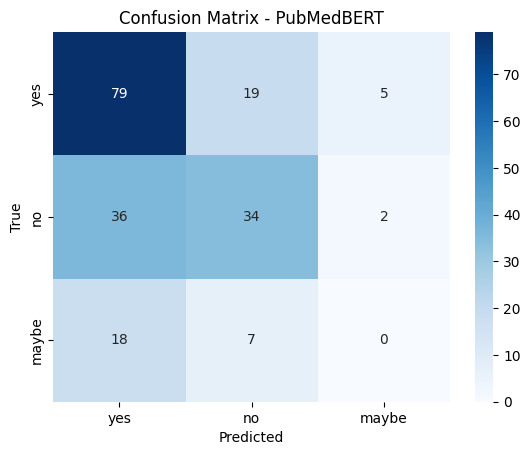

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

predictions = trainer.predict(dataset["test"])

preds = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids

cm = confusion_matrix(labels, preds)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["yes", "no", "maybe"],
            yticklabels=["yes", "no", "maybe"])

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - PubMedBERT")
plt.show()

## 16. Save Model

In [27]:
trainer.save_model("../models/pubmedbert_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
from transformers import AutoModelForSequenceClassification

model_name = "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext"

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

print("Model loaded successfully")

In [12]:
print("STEP: Loading model...")

from transformers import AutoModelForSequenceClassification

model_name = "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext"

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

print("STEP: Model created successfully")

STEP: Loading model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- 

STEP: Model created successfully
